In [94]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

# Q1

In [95]:
df = [{'mother height':58, 'daughter height':60},
     {'mother height':62, 'daughter height':60},
     {'mother height':60, 'daughter height':58},
     {'mother height':64, 'daughter height':60},
     {'mother height':67, 'daughter height':70},
     {'mother height':70, 'daughter height':72}]

df=pd.DataFrame(df)
df.to_csv('height.csv', index=False)

## SGD

In [96]:
n=len(df)

X=df['mother height'].values
Y=df['daughter height'].values

b0_sgd=0
b1_sgd=0
alpha=0.0001

for epoch in range(10000):
    for i in range(n):
        
        y_pred=b0_sgd+b1_sgd*X[i]
        
        error=y_pred-Y[i]
        
        b0_sgd=b0_sgd-alpha*error
        b1_sgd=b1_sgd-alpha*error*X[i]
        
print("b0 =", b0_sgd)
print("b1 =", b1_sgd)

b0 = -0.5189139980321302
b1 = 1.0228977716637215


In [97]:
Y_pred=b0_sgd+b1_sgd*X

mse=np.sum(Y_pred-Y)/n
rmse=np.sqrt(mse)

print("MSE =",mse)
print("RMSE =",rmse)

MSE = 1.101761169280851
RMSE = 1.0496481168852976


## BGD

In [98]:
b0_bgd=0
b1_bgd=0

for epoch in range(10000):
        
        y_pred=b0_bgd+b1_bgd*X
        
        error=y_pred-Y
        
        b0_bgd=b0_bgd-alpha*(1/n)*np.sum(error)
        b1_bgd=b1_bgd-alpha*(1/n)*np.sum(error*X)
        
print("b0 =", b0_bgd)
print("b1 =", b1_bgd)

b0 = -0.03855579776054928
b1 = 0.9988344242525825


In [99]:
Y_pred=b0_bgd+b1_bgd*X

mse=np.sum(Y_pred-Y)/n
rmse=np.sqrt(mse)

print("MSE =",mse)
print("RMSE =",rmse)

MSE = 0.05409680894510416
RMSE = 0.23258720718282028


## Pedhazur's Formula

In [100]:
y_mean=np.mean(Y)
x_mean=np.mean(X)

b1=np.sum((X-x_mean)*(Y-y_mean))/np.sum((X-x_mean)**2)
b0=y_mean-b1*x_mean

print("b0 =", b0)
print("b1 =", b1)

b0 = -13.249581239530976
b1 = 1.2060301507537687


In [101]:
Y_pred=b0+b1*X

mse=np.sum(Y_pred-Y)/n
rmse=np.sqrt(mse)

print("MSE =",mse)
print("RMSE =",rmse)

MSE = 4.736951571734001e-15
RMSE = 6.882551541204759e-08


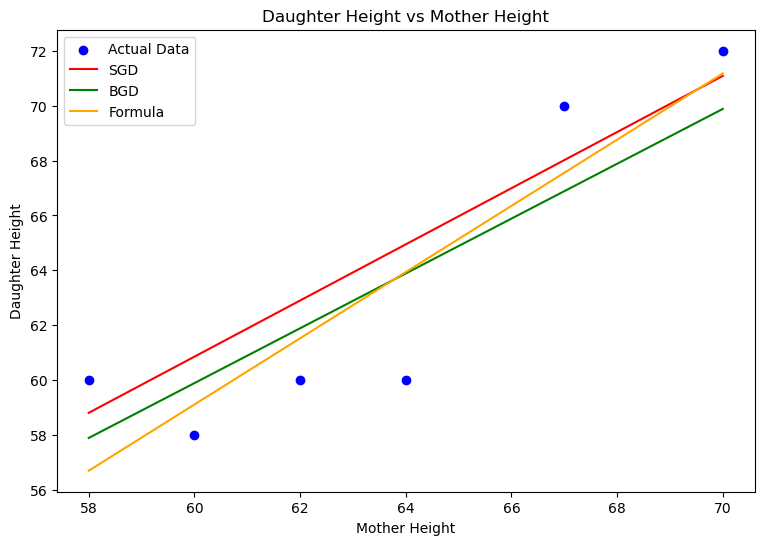

In [102]:
x_line=np.linspace(X.min(), X.max(), 100)

y_sgd=b0_sgd+b1_sgd*x_line
y_bgd=b0_bgd+b1_bgd*x_line
y=b0+b1*x_line

plt.figure(figsize=(9, 6))

plt.scatter(X, Y, color='blue', label='Actual Data')

plt.plot(x_line, y_sgd, color='red', label='SGD')
plt.plot(x_line, y_bgd, color='green', label='BGD')
plt.plot(x_line, y, color='orange', label='Formula')

plt.xlabel("Mother Height")
plt.ylabel("Daughter Height")
plt.title("Daughter Height vs Mother Height")

plt.legend()

plt.show()

## SGD with 4 epochs

In [103]:
b0_sgd=0
b1_sgd=0
alpha=0.0001

errors=[]
iterations=[]

iteration=0

for epoch in range(4):

    for i in range(n):

        y_pred=b0_sgd+b1_sgd*X[i]

        error=y_pred-Y[i]

        b0_sgd=b0_sgd-alpha*error
        b1_sgd=b1_sgd-alpha*error*X[i]

        iteration+=1

        errors.append(error)
        iterations.append(iteration)

print("b0 =", b0_sgd)
print("b1 =", b1_sgd)

b0 = 0.016406249586034958
b1 = 1.0149205396744159


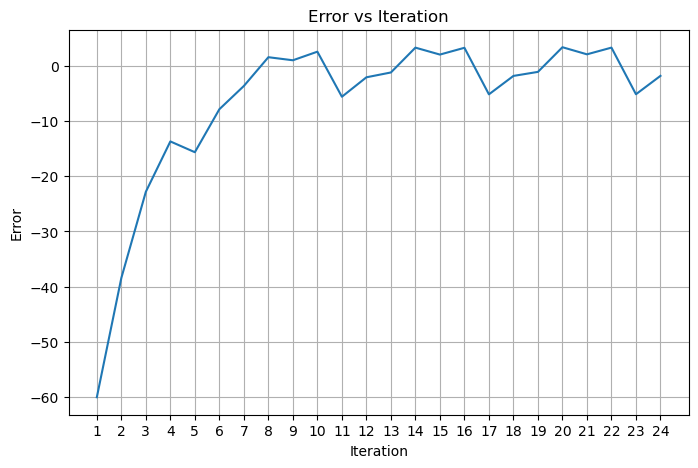

In [104]:
plt.figure(figsize=(8, 5))

plt.plot(iterations, errors)

plt.xlabel("Iteration")
plt.ylabel("Error")
plt.title("Error vs Iteration")

plt.xticks(range(1, 25))
plt.grid()

plt.show()

In [105]:
mother_height=63

pred_sgd=b0_sgd+b1_sgd*mother_height
pred_bgd=b0_bgd+b1_bgd * mother_height
pred_formula=b0+b1*mother_height

print("Prediction for mother height = 63")

print("SGD      :", pred_sgd)
print("BGD      :", pred_bgd)
print("Formula  :", pred_formula)

Prediction for mother height = 63
SGD      : 63.956400249074235
BGD      : 62.888012930152144
Formula  : 62.73031825795645


# Q2

In [106]:
df2 = [{'hours':1, 'pass':0},
     {'hours':2, 'pass':0},
     {'hours':3, 'pass':0},
     {'hours':4, 'pass':0},
     {'hours':5, 'pass':1},
     {'hours':6, 'pass':1},
     {'hours':7, 'pass':1},
     {'hours':8, 'pass':1}]

df2=pd.DataFrame(df2)
df2.to_csv('study_hours.csv', index=False)

## SGD

In [115]:
n=len(df2)

X=df2['hours'].values
Y=df2['pass'].values

b0_sgd = 0
b1_sgd = 0
alpha = 0.0001

errors = []
iterations = []

iteration = 0

for epoch in range(3):

    for i in range(n):

        y_pred = 1/(1+np.exp(-(b0_sgd+b1_sgd*X[i])))

        error=y_pred-Y[i]

        iteration+=1
        iterations.append(iteration)
        errors.append(error)

        b0_sgd=b0_sgd-alpha*error
        b1_sgd=b1_sgd-alpha*error*X[i]

print("b0 =", b0_sgd)
print("b1 =", b1_sgd)

print("Number of iterations:", len(iterations))
print("Number of errors:", len(errors))

b0 = -1.929082802657378e-06
b1 = 0.0023880819366232644
Number of iterations: 24
Number of errors: 24


In [108]:
df2['predicted_sgd']=df2['hours'].apply(lambda x: 1 if (1/(1+np.exp(-(b0_sgd+b1_sgd*x))))>=0.5 else 0)

accuracy=np.mean(df2['predicted_sgd']==df2['pass'])*100
print(f"Accuracy = {accuracy}%")

Accuracy = 50.0%


## BGD

In [113]:
b0_bgd=0
b1_bgd=0

errors = []
iterations = []

iteration = 0

for epoch in range(3):
        
        y_pred=1/(1+np.exp(-(b0_bgd+b1_bgd*X)))
        
        error=y_pred-Y
        
        iteration+=1
        iterations.append(iteration)
        errors.append(error)
        
        b0_bgd=b0_bgd-alpha*(1/n)*np.sum(error)
        b1_bgd=b1_bgd-alpha*(1/n)*np.sum(error*X)
        
print("b0 =", b0_bgd)
print("b1 =", b1_bgd)

print("Number of iterations:", len(iterations))
print("Number of errors:", len(errors))

b0 = -3.3742543840420416e-08
b1 = 0.00029980879192679003
Number of iterations: 3
Number of errors: 3


In [110]:
df2['predicted_sgd']=df2['hours'].apply(lambda x: 1 if (1/(1+np.exp(-(b0_bgd+b1_bgd*x))))>=0.5 else 0)

accuracy=np.mean(df2['predicted_sgd']==df2['pass'])*100
print(f"Accuracy = {accuracy}%")

Accuracy = 50.0%


In [111]:
prob_3_5=1/(1+np.exp(-(b0_sgd+b1_sgd*3.5)))

prob_7_5=1/(1+np.exp(-(b0_sgd+b1_sgd*7.5)))

print("Probability of passing for 3.5 hours =", prob_3_5)
print("Probability of passing for 7.5 hours =", prob_7_5)

Probability of passing for 3.5 hours = 0.5020890772673939
Probability of passing for 7.5 hours = 0.5044770517040605


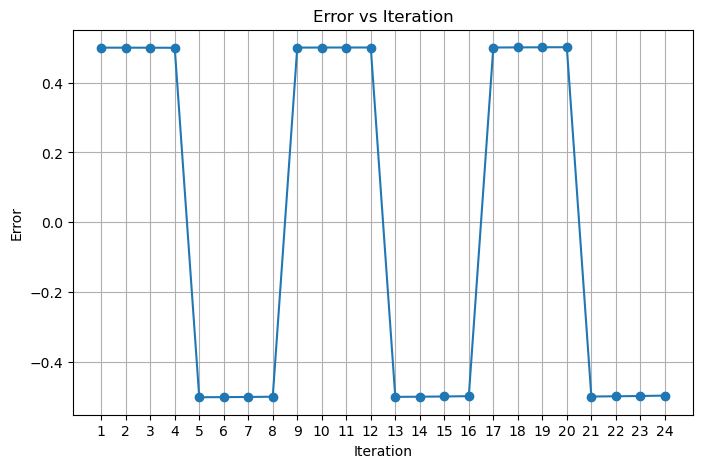

In [116]:
plt.figure(figsize=(8, 5))

plt.plot(iterations, errors, marker='o')

plt.xlabel("Iteration")
plt.ylabel("Error")
plt.title("Error vs Iteration")

plt.xticks(range(1, 25))
plt.grid()

plt.show()

# Q3

In [121]:
data={"X1": [4, 2, 1, 3, 1, 6],
    "X2": [1, 8, 0, 2, 4, 7],
    "Y":  [2, -14, 1, -1, -7, -8]}

df3=pd.DataFrame(data)

df3.to_csv("logistic_data.csv", index=False)

X1=df3["X1"].values
X2=df3["X2"].values

df3['Y_binary']=(df3['Y']>0).astype(int)

Y=df3["Y_binary"].values

n=len(Y)

b0=0
b1=0
b2=0

alpha=0.01

for epoch in range(10000):

    for i in range(n):

        z = b0 + b1 * X1[i] + b2 * X2[i]

        y_pred = 1 / (1 + np.exp(-z))

        error = y_pred - Y[i]

        b0 = b0 - alpha * error
        b1 = b1 - alpha * error * X1[i]
        b2 = b2 - alpha * error * X2[i]

print("b0 =", b0)
print("b1 =", b1)
print("b2 =", b2)

b0 = 2.3033188549727797
b1 = 2.3883216730573347
b2 = -6.969024984844045
